In [1]:
import pickle as pkl
import numpy as np
import sys
import matplotlib.pyplot as plt
from scipy.interpolate import LSQUnivariateSpline
import os
import mplhep as hep
hep.style.use("CMS")
# set prop cycle to set1
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)
#os.chdir("..")
sys.path.append("./src")
os.getcwd()

'/mnt/8A04C21E04C20CDF/wsLinux/unfold'

In [2]:
with open('./inputs/rhoInputs/pythia_all.pkl', "rb") as f:
    output_pythia= pkl.load( f )


with open('./inputs/rhoInputs/herwig_all.pkl', "rb") as f:
    output_herwig= pkl.load( f )

In [3]:
os.getcwd()
ptlist = [r"0 - 200 GeV", r"200-290 GeV", r"290-400 GeV", r"400-$\infty$ GeV"]

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


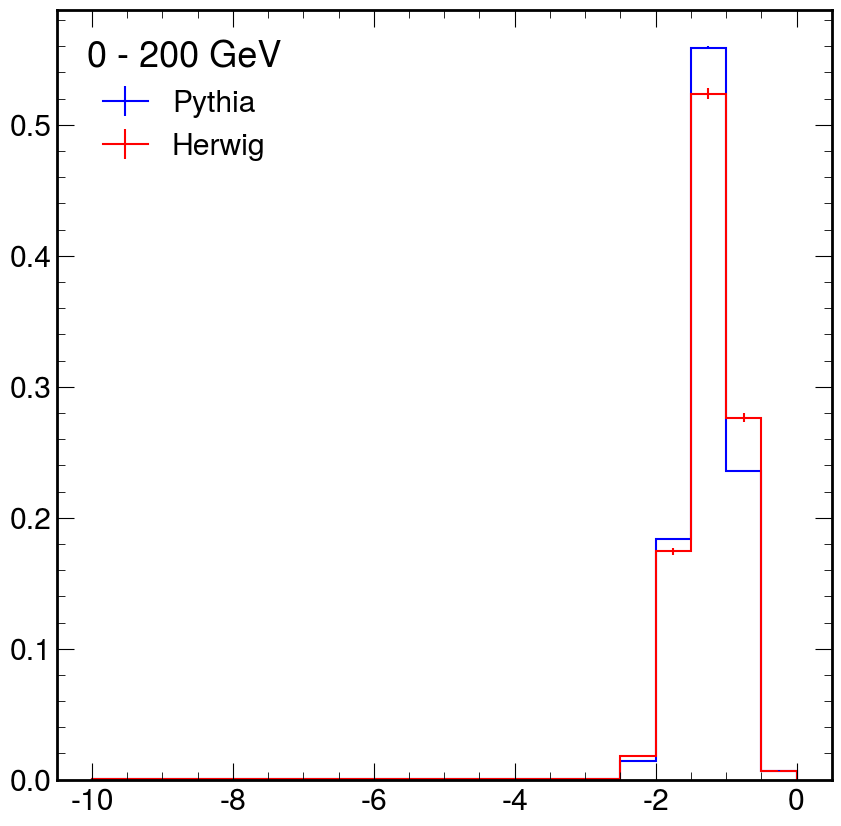

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


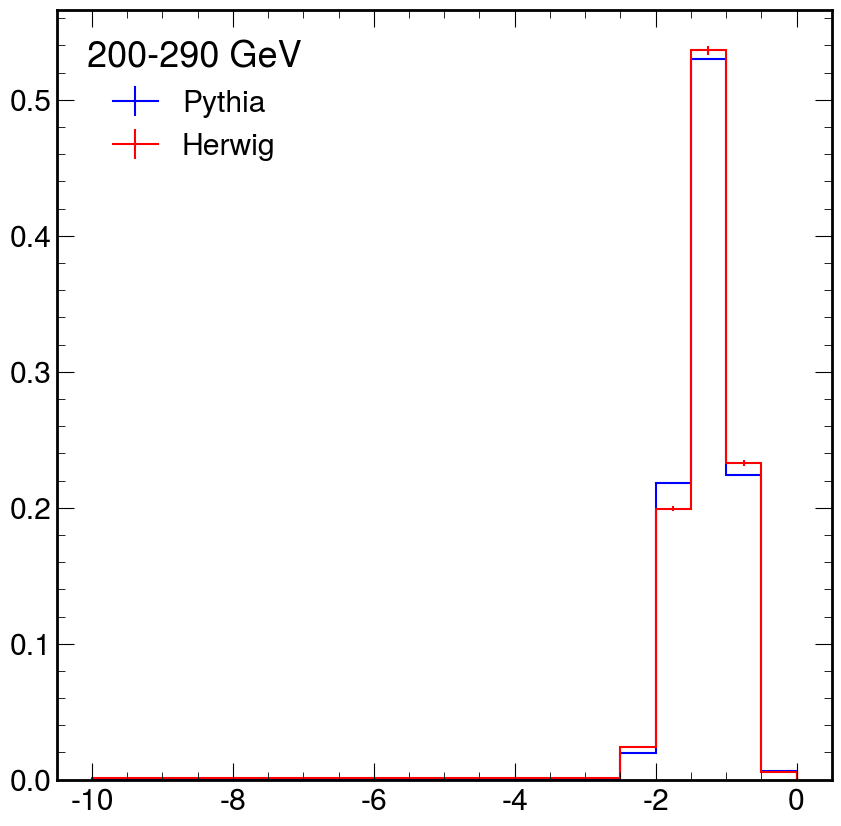

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


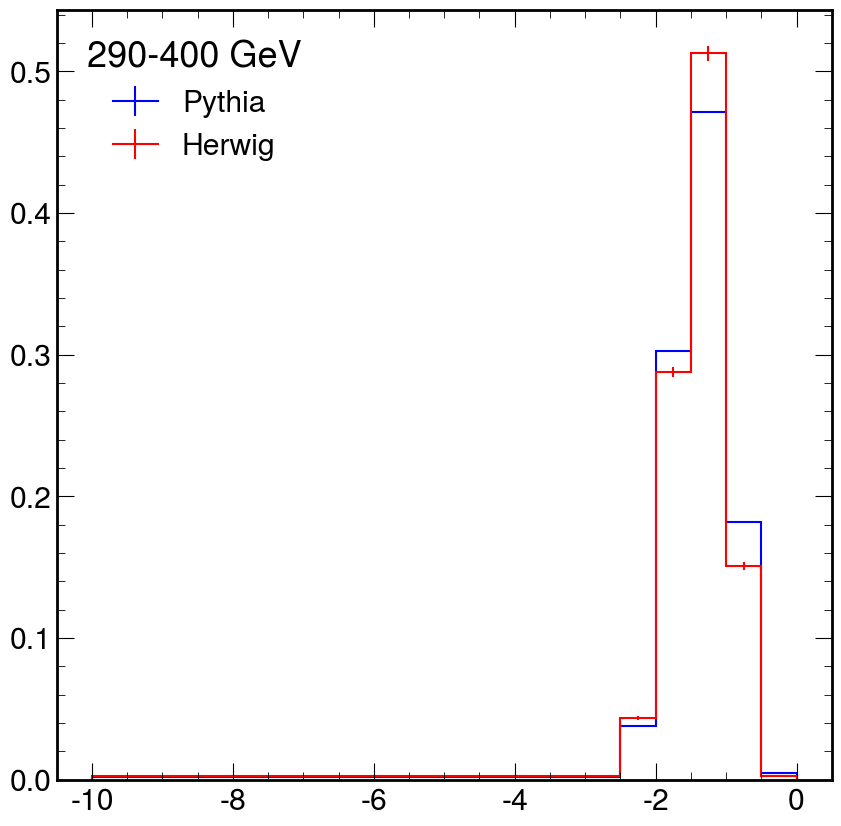

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


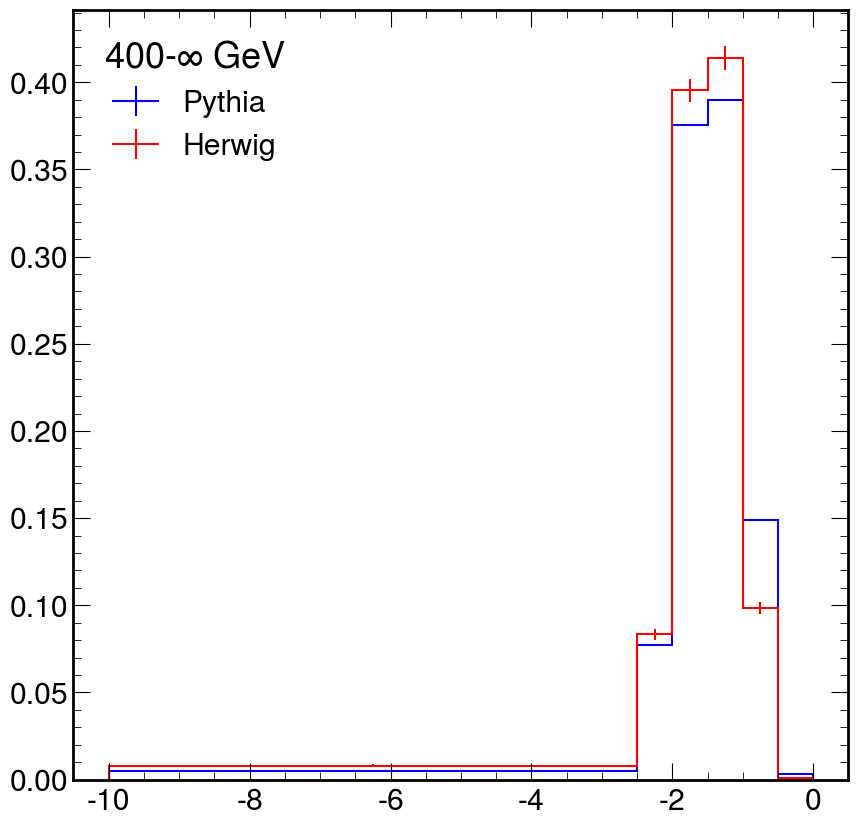

In [4]:
groomed = False
npt = 4
import mplhep as hep
from unfold.tools import binning
from unfold.utils.integrate_and_rebin import rebin_hist
bins = binning.bin_edges(groomed=groomed)
gen_rho_edges_by_pt = bins.gen_rho_edges_by_pt
for i in range(npt):
    h = output_pythia['ptjet_rhojet_g_gen'].project('ptgen', 'mpt_gen','systematic') if groomed else output_pythia['ptjet_rhojet_u_gen'].project('ptgen', 'mpt_gen','systematic')
    h_herwig = output_herwig['ptjet_rhojet_g_gen'].project('ptgen', 'mpt_gen','systematic') if groomed else output_herwig['ptjet_rhojet_u_gen'].project('ptgen', 'mpt_gen','systematic')

    h = rebin_hist(h, 'mpt_gen', gen_rho_edges_by_pt[i], )
    h_herwig = rebin_hist(h_herwig,  'mpt_gen', gen_rho_edges_by_pt[i],)
    h_vals = h[i, :, 'nominal'].values()
    h_herwig_vals = h_herwig[i, :, 'nominal'].values()

    h_errs = h[i, :, 'nominal'].variances()**0.5
    h_herwig_errs = h_herwig[i, :, 'nominal'].variances()**0.5
    h_sum = np.sum(h_vals)
    h_herwig_sum = np.sum(h_herwig_vals)
    h_vals = h_vals / h_sum
    h_errs = h_errs / h_sum

    h_herwig_vals = h_herwig_vals / h_herwig_sum
    h_herwig_errs = h_herwig_errs / h_herwig_sum

    hep.histplot(h_vals, bins = gen_rho_edges_by_pt[i], yerr=h_errs, label='Pythia', histtype='step', color='blue');
    hep.histplot(h_herwig_vals, bins = gen_rho_edges_by_pt[i], yerr=h_herwig_errs, label='Herwig', histtype='step', color='red');
    plt.legend(title  = ptlist[i])
    plt.show()


/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


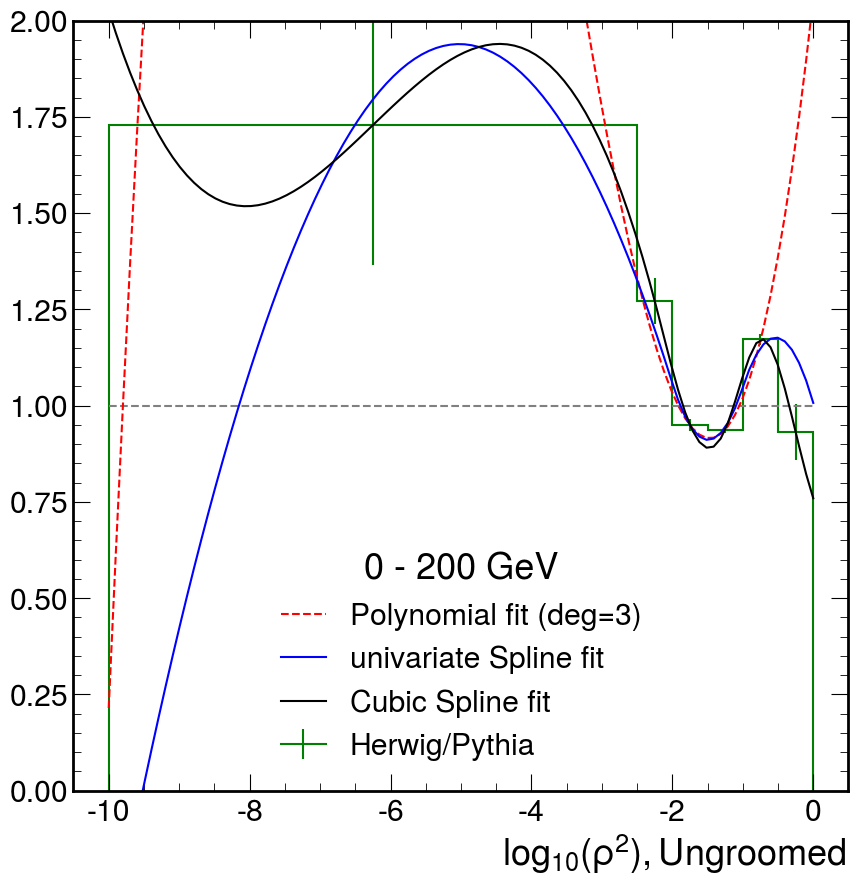

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


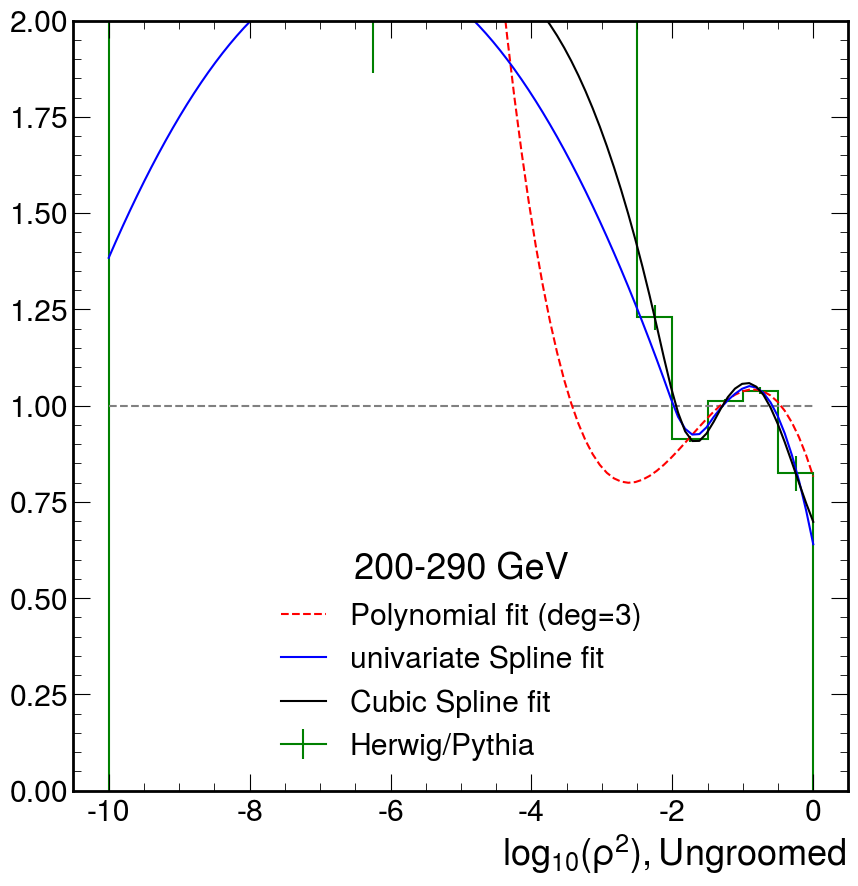

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


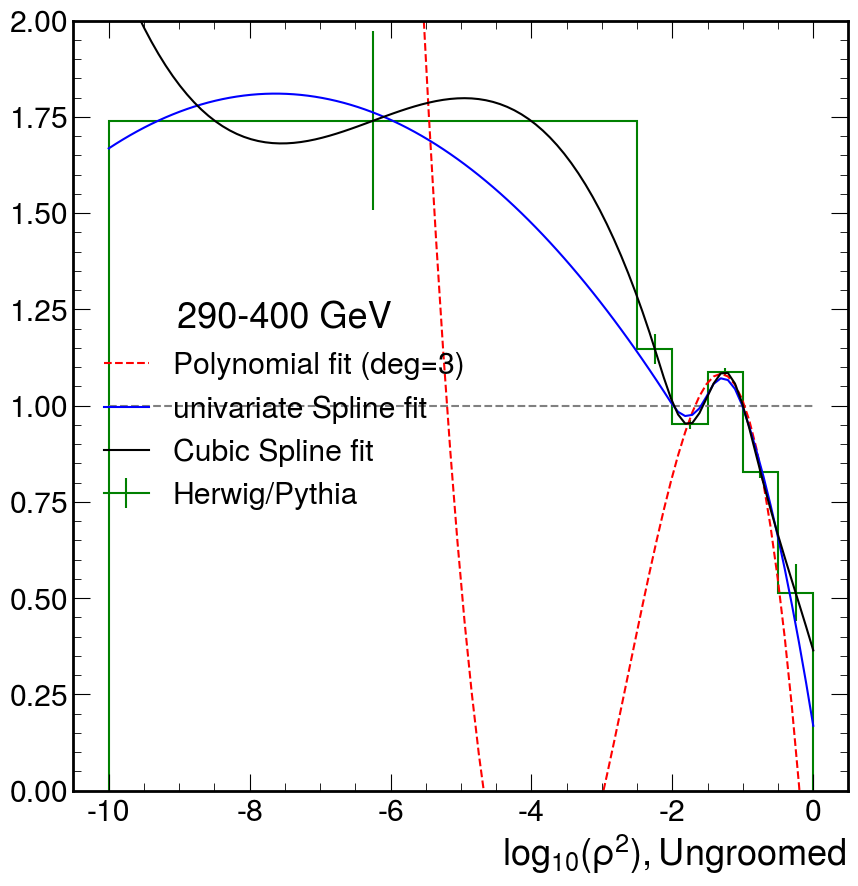

/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():


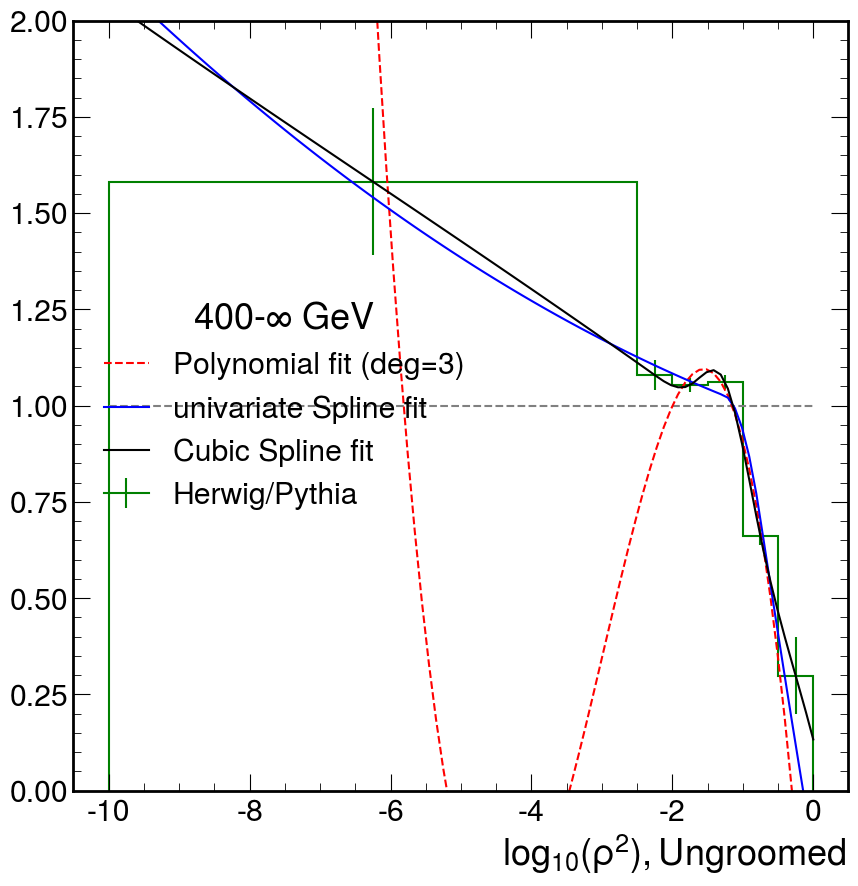

In [5]:
from numpy.polynomial import Polynomial
from scipy.interpolate import UnivariateSpline, CubicSpline

gen_rho_edges_by_pt = bins.gen_rho_edges_by_pt[0]
spl_list = []
for i in range(npt):
    h = output_pythia['ptjet_rhojet_g_gen'].project('ptgen', 'mpt_gen','systematic') if groomed else output_pythia['ptjet_rhojet_u_gen'].project('ptgen', 'mpt_gen','systematic')
    h_herwig = output_herwig['ptjet_rhojet_g_gen'].project('ptgen', 'mpt_gen','systematic') if groomed else output_herwig['ptjet_rhojet_u_gen'].project('ptgen', 'mpt_gen','systematic')

    h = rebin_hist(h, 'mpt_gen', gen_rho_edges_by_pt, )
    h_herwig = rebin_hist(h_herwig,  'mpt_gen', gen_rho_edges_by_pt,)
    h_vals = h[i, :, 'nominal'].values()
    h_herwig_vals = h_herwig[i, :, 'nominal'].values()

    h_errs = h[i, :, 'nominal'].variances()**0.5
    h_herwig_errs = h_herwig[i, :, 'nominal'].variances()**0.5
    h_sum = np.sum(h_vals)
    h_herwig_sum = np.sum(h_herwig_vals)
    h_vals = h_vals / h_sum
    h_errs = h_errs / h_sum

    h_herwig_vals = h_herwig_vals / h_herwig_sum
    h_herwig_errs = h_herwig_errs / h_herwig_sum

    ratio = h_herwig_vals / h_vals
    ratio_errs = ratio * np.sqrt((h_herwig_errs / h_herwig_vals)**2 + (h_errs / h_vals)**2)

    hep.histplot(ratio, bins = gen_rho_edges_by_pt, yerr=ratio_errs, label='Herwig/Pythia', histtype='step', color='green');
    plt.hlines(1, gen_rho_edges_by_pt[0], gen_rho_edges_by_pt[-1], colors='gray', linestyles='dashed')

    bin_centers = (np.array(gen_rho_edges_by_pt[:-1]) + np.array(gen_rho_edges_by_pt[1:])) / 2
    filter = (ratio > 0) & (ratio_errs > 0)
    poly_fit = Polynomial.fit(bin_centers[filter], ratio[filter], deg=3, w=1/ratio_errs[filter]**2)

    s = len(bin_centers[filter])*2  # good starting point; try 0.5*len, 2*len, etc.
    cs = CubicSpline(bin_centers[filter], ratio[filter], bc_type='natural')
    spl = UnivariateSpline(bin_centers[filter], ratio[filter], w=1.0/ratio_errs[filter], k=2, s=s)

    x_smooth = np.linspace(gen_rho_edges_by_pt[0], gen_rho_edges_by_pt[-1], 100)
    y_smooth = spl(x_smooth)
    y_cs = cs(x_smooth)

    plt.plot(x_smooth, poly_fit(x_smooth), 'r--', label='Polynomial fit (deg=3)')
    plt.plot(x_smooth, y_smooth, 'b-', label='univariate Spline fit')
    plt.plot(x_smooth, y_cs, 'k-', label='Cubic Spline fit')
    plt.ylim(0.0, 2)
    plt.legend(title = ptlist[i])
    spl_list.append(spl)
    plt.xlabel(r"$log_{10}(\rho^2), Groomed$ " if groomed else r"$log_{10}(\rho^2), Ungroomed$ ")
    plt.show()

pt_edges = np.array([0, 200, 290, 400, 13000.0])

rho_grids = []
w_grids = []

for k in range(len(pt_edges) - 1):
    # choose rho range for this pt bin (use your gen rho edges for that pt bin)
    rho_edges = np.asarray(gen_rho_edges_by_pt)
    rho_min, rho_max = rho_edges[0], rho_edges[-1]

    rho_grid = np.linspace(rho_min, rho_max, 2000)
    w_grid = spl_list[k](rho_grid)

    # safety clamp (tune these bounds)
    w_grid = np.clip(w_grid, 0.5, 1.5)

    rho_grids.append(rho_grid)
    w_grids.append(w_grid)
filename = './data/spline_groomed.npz' if groomed else './data/spline_ungroomed.npz'
np.savez(
    filename,
    pt_edges=pt_edges,
    rho_grids=np.array(rho_grids, dtype=object),
    w_grids=np.array(w_grids, dtype=object),
)


/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type() == hist.storage.Weight():
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:21: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  hnew = hist.Hist(*axes, name=h.name, storage=h._storage_type())
/mnt/8A04C21E04C20CDF/wsLinux/unfold/src/unfold/utils/integrate_and_rebin.py:42: FutureWarning: Accessing storage type has changed from _storage_type to storage_type, and will be removed in future.
  if hnew._storage_type(

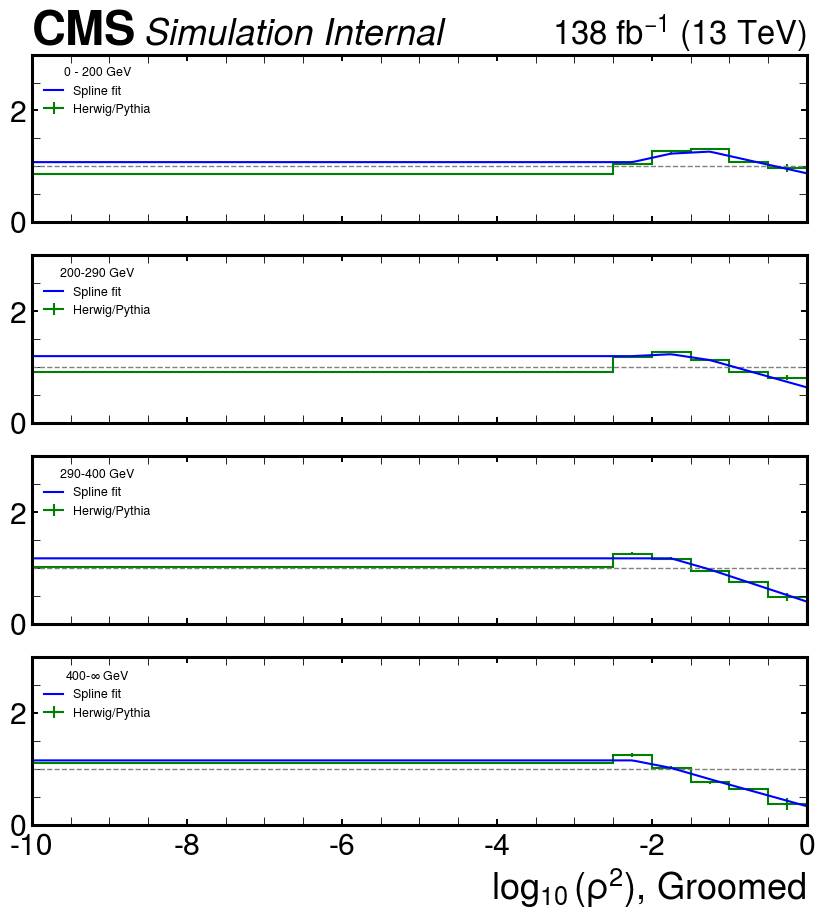

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.interpolate import UnivariateSpline, CubicSpline
from numpy.polynomial import Polynomial

groomed = True
gen_rho_edges_by_pt = bins.gen_rho_edges_by_pt[0]

# --- create ONE figure with npt stacked axes ---
fig, axs = plt.subplots(
    npt, 1,
    sharex=True,
    #figsize=(6.2, 1.55*npt),          # tune height per panel
    gridspec_kw={"hspace": 0.2},     # small vertical gap like your image
    constrained_layout=False
)

# if npt == 1, axs isn't a list; normalize it
axs = np.atleast_1d(axs)

spl_list = []

for i in range(npt):
    ax = axs[i]

    h = (output_pythia['ptjet_rhojet_g_gen'].project('ptgen', 'mpt_gen','systematic')
         if groomed else
         output_pythia['ptjet_rhojet_u_gen'].project('ptgen', 'mpt_gen','systematic'))

    h_herwig = (output_herwig['ptjet_rhojet_g_gen'].project('ptgen', 'mpt_gen','systematic')
                if groomed else
                output_herwig['ptjet_rhojet_u_gen'].project('ptgen', 'mpt_gen','systematic'))

    h = rebin_hist(h, 'mpt_gen', gen_rho_edges_by_pt)
    h_herwig = rebin_hist(h_herwig, 'mpt_gen', gen_rho_edges_by_pt)

    h_vals = h[i, :, 'nominal'].values()
    h_herwig_vals = h_herwig[i, :, 'nominal'].values()

    h_errs = np.sqrt(h[i, :, 'nominal'].variances())
    h_herwig_errs = np.sqrt(h_herwig[i, :, 'nominal'].variances())

    # normalize
    h_sum = np.sum(h_vals)
    h_herwig_sum = np.sum(h_herwig_vals)

    h_vals = h_vals / h_sum
    h_errs = h_errs / h_sum
    h_herwig_vals = h_herwig_vals / h_herwig_sum
    h_herwig_errs = h_herwig_errs / h_herwig_sum

    ratio = h_herwig_vals / h_vals
    ratio_errs = ratio * np.sqrt((h_herwig_errs / h_herwig_vals)**2 + (h_errs / h_vals)**2)

    # --- plot on THIS axis (ax=...) ---
    hep.histplot(
        ratio,
        bins=gen_rho_edges_by_pt,
        yerr=ratio_errs,
        histtype="step",
        color="green",
        ax=ax,
        label="Herwig/Pythia"
    )
    ax.hlines(1, gen_rho_edges_by_pt[0], gen_rho_edges_by_pt[-1],
              colors="gray", linestyles="dashed", linewidth=1)
    if i == 0:
        hep.cms.label("Internal", data = False, lumi = 138, ax=ax)
    
    # fits
    bin_centers = (np.asarray(gen_rho_edges_by_pt[:-1]) + np.asarray(gen_rho_edges_by_pt[1:])) / 2
    bin_centers[0] = -10e10  # setting overflow far away
    mask = (ratio > 0) & (ratio_errs > 0) & np.isfinite(ratio) & np.isfinite(ratio_errs)

    s = np.sum(mask) * 2
    cs = CubicSpline(bin_centers[mask], ratio[mask], bc_type="natural")
    spl = UnivariateSpline(bin_centers[mask], ratio[mask], w=1.0/ratio_errs[mask], k=1, s=s)

    x_smooth = np.linspace(gen_rho_edges_by_pt[0], gen_rho_edges_by_pt[-1], 200)
    ax.plot(x_smooth, spl(x_smooth), "b-", linewidth=1.5, label="Spline fit")
    
    ax.set_xlim(-10, 0)  # adjust as needed
    ax.set_ylim(0.0, 3.0)
    ax.legend(title=str(ptlist[i]), loc="upper left", fontsize=9, title_fontsize=9, frameon=False)

    # make the “boxed subpanel” look like your screenshot
    for spine in ax.spines.values():
        spine.set_linewidth(2.2)
    ax.tick_params(direction="in", length=4, width=1.4)

    spl_list.append(spl)

# common x-label only on bottom axis
axs[-1].set_xlabel(r"$\log_{10}(\rho^2)$, Groomed" if groomed else r"$\log_{10}(\rho^2)$, Ungroomed")
for ax in axs[:-1]:
    ax.set_xlabel("")

# # optional: outer border box around the whole figure
# fig.patch.set_edgecolor("black")
# fig.patch.set_linewidth(3)

plt.show()


In [19]:
check_obj = np.array(w_grids)
#check for nans
print(np.isnan(check_obj).any())

False


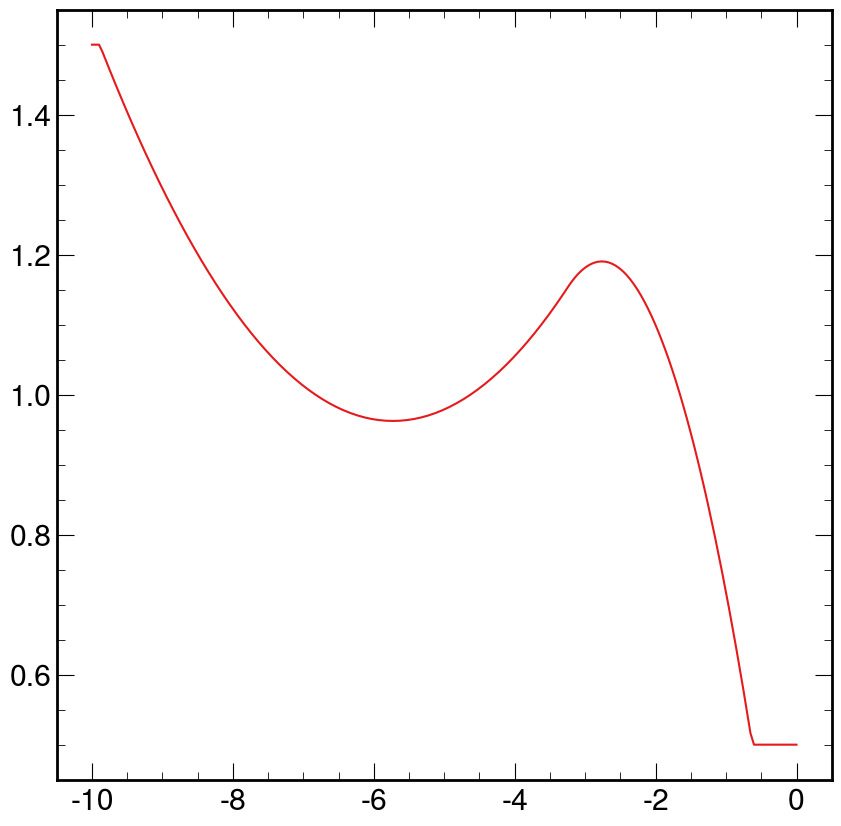

In [20]:
import numpy as np

class PtRhoWeighter:
    def __init__(self, npz_path: str):
        dat = np.load(npz_path, allow_pickle=True)
        self.pt_edges = np.asarray(dat["pt_edges"], dtype=float)
        self.rho_grids = dat["rho_grids"]   # object array
        self.w_grids = dat["w_grids"]       # object array

    def _pt_bin(self, pt: float) -> int:
        k = np.searchsorted(self.pt_edges, pt, side="right") - 1
        return int(np.clip(k, 0, len(self.pt_edges) - 2))

    def weight(self, pt: float, rho: float) -> float:
        k = self._pt_bin(pt)
        x = np.asarray(self.rho_grids[k], dtype=float)
        w = np.asarray(self.w_grids[k], dtype=float)
        return float(np.interp(rho, x, w, left=w[0], right=w[-1]))

    def weight_array(self, pt_arr, rho_arr):
        pt_arr = np.asarray(pt_arr, dtype=float)
        rho_arr = np.asarray(rho_arr, dtype=float)
        out = np.empty_like(rho_arr, dtype=float)

        k_arr = np.searchsorted(self.pt_edges, pt_arr, side="right") - 1
        k_arr = np.clip(k_arr, 0, len(self.pt_edges) - 2)

        for k in range(len(self.pt_edges) - 1):
            mask = (k_arr == k)
            if not np.any(mask):
                continue
            x = np.asarray(self.rho_grids[k], dtype=float)
            w = np.asarray(self.w_grids[k], dtype=float)
            out[mask] = np.interp(rho_arr[mask], x, w, left=w[0], right=w[-1])

        return out

weighter = PtRhoWeighter("./data/spline_groomed.npz" if groomed else "./data/spline_ungroomed.npz")
plt.plot(np.linspace(-10, 0 ,200), weighter.weight_array( np.full( 200, 401), np.linspace(-10, 0 ,200),), label='Weight from Spline')